<a href="https://colab.research.google.com/github/mjss26/EMSC2010-W8-P1-MSS/blob/main/EMSC2010_W8_P1_NB3_MSS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Question: In what year will the women's Olympic 100 m champion finish faster than the men's Olympic 100 m champion?

Import libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Input women's historical data where:
* ```W_year```: year of the women's Olympic final
* ```W_time```: time of the winner (in seconds)

In [ ]:
W_year = np.array([1928,1932,1936,1948,1952,1956,1960,1964,1968,1972,1976,1980,1984,1988,1992,1996,2000,2004,2008,2012,2016,2020,2024])
W_time = np.array([12.2,11.9,11.5,11.9,11.5,11.5,11,11.4,11.08,11.07,11.08,11.06,10.97,10.54,10.82,10.94,10.75,10.93,10.78,10.75,10.71,10.61,10.72])

Input men's historical data where:
* ```M_year```: year of the men's Olympic final
* ```M_time```: time of the winner (in seconds)

In [ ]:
M_year = np.array([1900,1904,1908,1912,1920,1924,1928,1932,1936,1948,1952,1956,1960,1964,1968,1972,1976,1980,1984,1988,1992,1996,2000,2004,2008,2012,2016,2020,2024])
M_time = np.array([11,11,10.8,10.8,10.8,10.6,10.8,10.3,10.3,10.3,10.4,10.5,10.5,10,9.95,10.14,10.06,10.25,9.99,9.92,9.96,9.84,9.87,9.85,9.69,9.63,9.81,9.8,9.79])

Visualize the historical data.

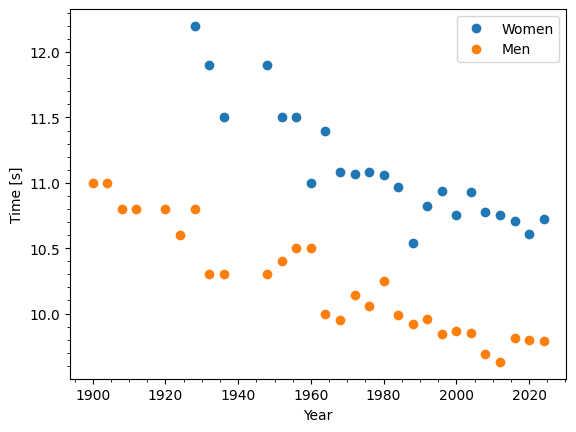

In [ ]:
plt.plot(W_year,W_time,'o',label = 'Women')
plt.plot(M_year,M_time,'o',label = 'Men')
plt.xlabel('Year')
plt.ylabel('Time [s]')
plt.legend()
plt.minorticks_on()
plt.show()

To simplify the problem, you can assume that both the women's and men's times follow a straight-line with respect to year.

In [ ]:
!pip install bambi #system command to install bambi package

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 13.6 MB/s eta 0:00:00


In [ ]:
import numpy as np #for working with numerical arrays
import matplotlib.pyplot as plt #for plotting
import bambi as bmb #for automated Bayesian regression
import arviz as az #for analysis of Bayesian models
import pandas as pd #bambi requires us to work with pandas dataframes

In [ ]:
#bambi has to have data in a dataframe #WOMEN
data = pd.DataFrame({"x": W_year, "y": W_time}) #put the data into a dataframe with variable names "x" and "y". #x is dist down stream, Y is grain size
model = bmb.Model("y ~ x", data) #setup the first-order polynomial model #essentially means Y can be predicted by X
idata = model.fit(draws=2000, tune=2000, chains=8) #sample the posteriors #8 chains to get multiple outcomes

Output()

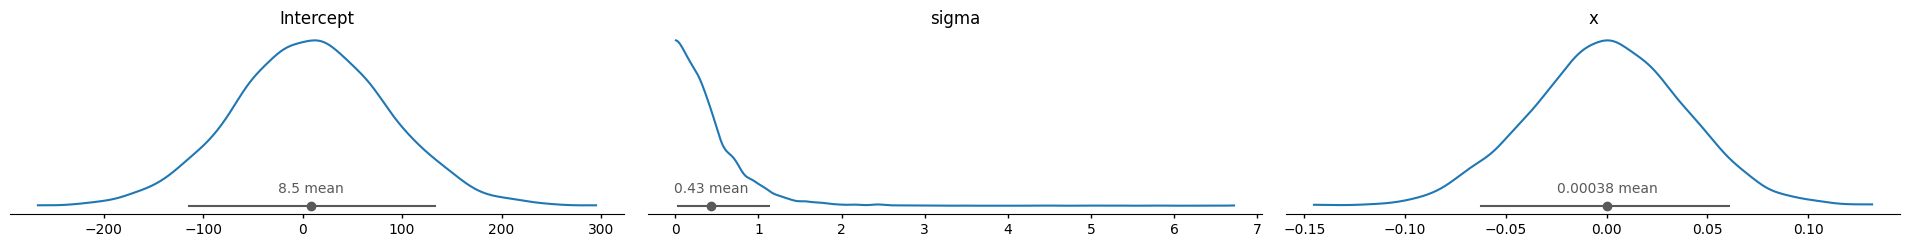

In [ ]:
model.plot_priors() #women
plt.tight_layout()
plt.show()

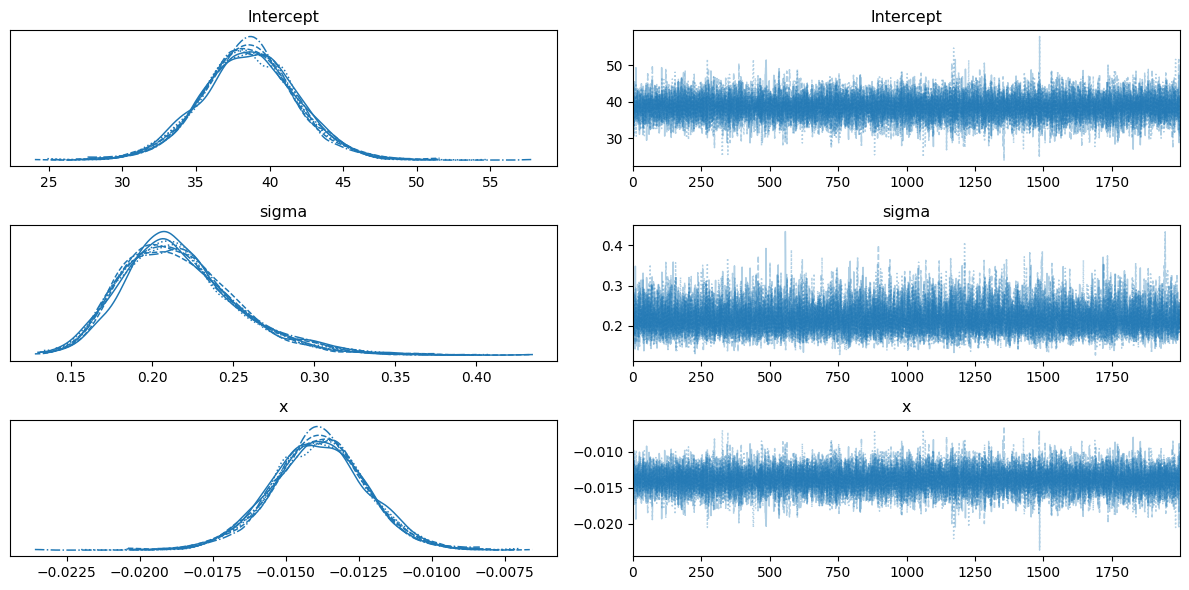

In [ ]:
az.plot_trace(idata);
plt.tight_layout() #this spaces the plots out so that they don't overlap

/tmp/ipykernel_36826/3873497329.py:13: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(y_mean_draws, hdi_prob=0.95)


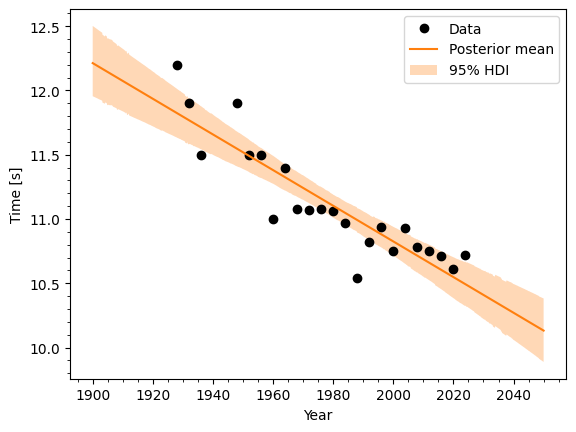

In [ ]:
x_range = np.linspace(1900, 2050, 1000) # Predict across a range of x values from 1 to 11 #100 data points between 1 and 11
new_data = pd.DataFrame({"x": x_range}) #dataframe with the new x-values
model.predict(idata, data=new_data, kind='response_params') #predict the distribution of regression lines at each x-value

# Make random draws from the posterior of the regression lines
y_mean_draws = idata.posterior["mu"].values

# Reshape to (total_draws, x_points)
y_mean_draws = y_mean_draws.reshape(-1, len(x_range))

# Compute posterior mean and HDI at each x point
posterior_mean = y_mean_draws.mean(axis=0)
hdi = az.hdi(y_mean_draws, hdi_prob=0.95)

# Plot the results
plt.plot(W_year, W_time, 'ok', label="Data")
plt.plot(x_range, posterior_mean, color="C1", label="Posterior mean")
plt.fill_between(
    x_range,
    hdi[:, 0],
    hdi[:, 1],
    alpha=0.3,
    color="C1",
    label="95% HDI",
    edgecolor = None
)
plt.xlabel('Year - women')
plt.ylabel('Time [s]')
plt.legend()
plt.minorticks_on()


#dark orange line means average grain size at dist point
#lighter orange is uncertainty of average grain size

In [ ]:
#bambi has to have data in a dataframe #MEN
data = pd.DataFrame({"x": M_year, "y": M_time}) #put the data into a dataframe with variable names "x" and "y". #x is dist down stream, Y is grain size
model = bmb.Model("y ~ x", data) #setup the first-order polynomial model #essentially means Y can be predicted by X
idata = model.fit(draws=2000, tune=2000, chains=8) #sample the posteriors #8 chains to get multiple outcomes

Output()

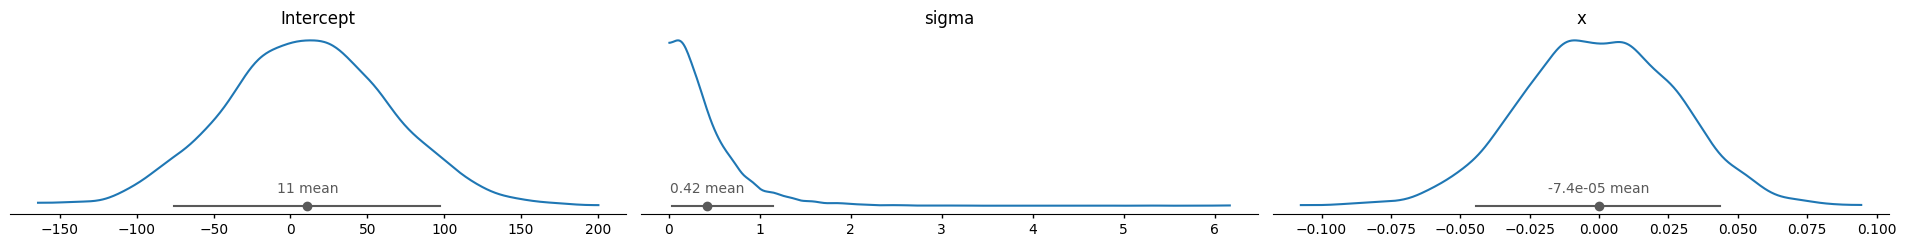

In [ ]:
model.plot_priors() #men
plt.tight_layout()
plt.show()

/tmp/ipykernel_36826/3132824884.py:13: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(y_mean_draws, hdi_prob=0.95)


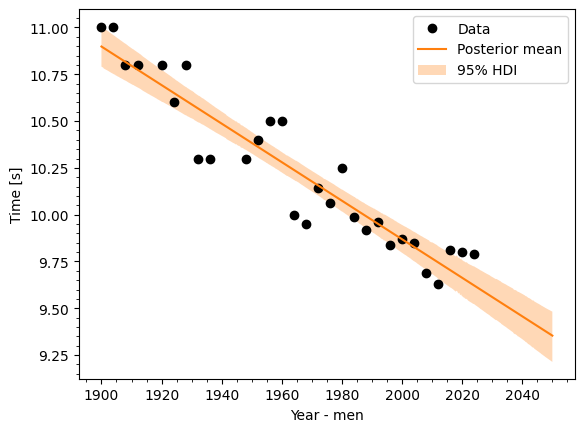

In [ ]:
x_range = np.linspace(1900, 2050, 1000) # Predict across a range of x values from 1 to 11 #100 data points between 1 and 11
new_data = pd.DataFrame({"x": x_range}) #dataframe with the new x-values
model.predict(idata, data=new_data, kind='response_params') #predict the distribution of regression lines at each x-value

# Make random draws from the posterior of the regression lines
y_mean_draws = idata.posterior["mu"].values

# Reshape to (total_draws, x_points)
y_mean_draws = y_mean_draws.reshape(-1, len(x_range))

# Compute posterior mean and HDI at each x point
posterior_mean = y_mean_draws.mean(axis=0)
hdi = az.hdi(y_mean_draws, hdi_prob=0.95)

# Plot the results
plt.plot(M_year, M_time, 'ok', label="Data")
plt.plot(x_range, posterior_mean, color="C1", label="Posterior mean")
plt.fill_between(
    x_range,
    hdi[:, 0],
    hdi[:, 1],
    alpha=0.3,
    color="C1",
    label="95% HDI",
    edgecolor = None
)
plt.xlabel('Year - men')
plt.ylabel('Time [s]')
plt.legend()
plt.minorticks_on()


#dark orange line means average grain size at dist point
#lighter orange is uncertainty of average grain size

### Combined Plot of Women's and Men's 100m Olympic Sprint Times

Output()

/tmp/ipykernel_36826/1430260420.py:11: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_women = az.hdi(y_mean_draws_women, hdi_prob=0.95)


Output()

/tmp/ipykernel_36826/1430260420.py:20: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_men = az.hdi(y_mean_draws_men, hdi_prob=0.95)


Predicted year when women's champion will finish faster than men's champion: 2270
Predicted time at intersection: 7.09 seconds


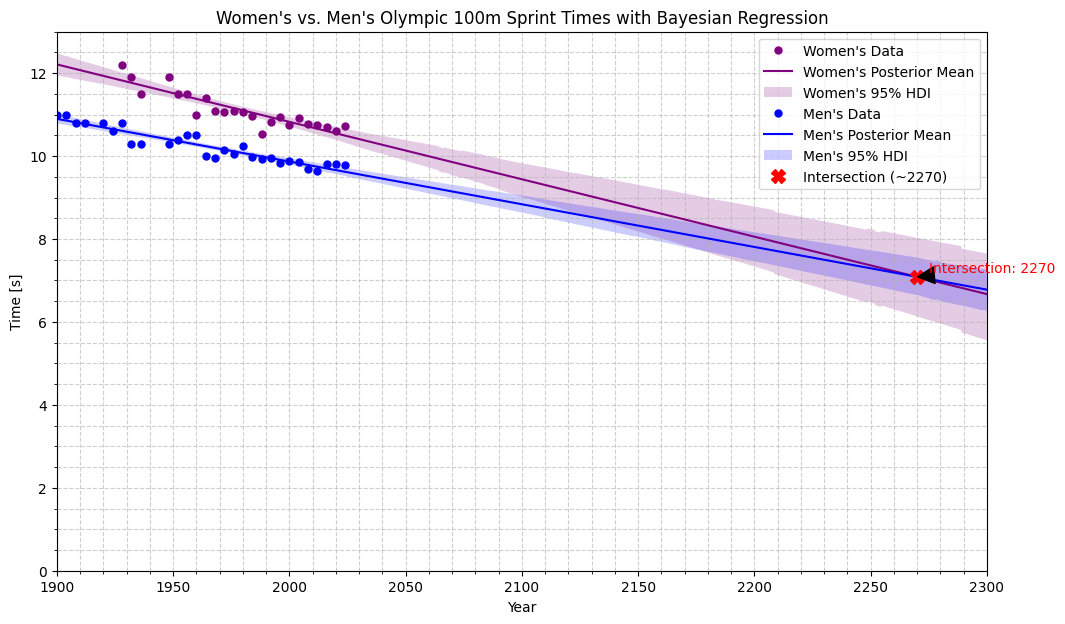

In [ ]:
x_range = np.linspace(1900, 2300, 1000)
new_data = pd.DataFrame({"x": x_range})

# --- Women's Data Prediction ---
data_women = pd.DataFrame({"x": W_year, "y": W_time})
model_women = bmb.Model("y ~ x", data_women)
idata_women = model_women.fit(draws=2000, tune=2000, chains=8)
model_women.predict(idata_women, data=new_data, kind='response_params')
y_mean_draws_women = idata_women.posterior["mu"].values.reshape(-1, len(x_range))
posterior_mean_women = y_mean_draws_women.mean(axis=0)
hdi_women = az.hdi(y_mean_draws_women, hdi_prob=0.95)

# --- Men's Data Prediction ---
data_men = pd.DataFrame({"x": M_year, "y": M_time})
model_men = bmb.Model("y ~ x", data_men)
idata_men = model_men.fit(draws=2000, tune=2000, chains=8)
model_men.predict(idata_men, data=new_data, kind='response_params')
y_mean_draws_men = idata_men.posterior["mu"].values.reshape(-1, len(x_range))
posterior_mean_men = y_mean_draws_men.mean(axis=0)
hdi_men = az.hdi(y_mean_draws_men, hdi_prob=0.95)

# --- Find Intersection Point ---
# Find the first index where women's posterior mean time is less than or equal to men's
intersection_idx = np.where(posterior_mean_women <= posterior_mean_men)[0]

if len(intersection_idx) > 0:
    # Get the year and time at the first intersection
    first_intersection_idx = intersection_idx[0]
    intersection_year = x_range[first_intersection_idx]
    intersection_time_women = posterior_mean_women[first_intersection_idx]
    intersection_time_men = posterior_mean_men[first_intersection_idx]

    print(f"Predicted year when women's champion will finish faster than men's champion: {int(np.ceil(intersection_year))}")
    print(f"Predicted time at intersection: {intersection_time_women:.2f} seconds")

# --- Plotting ---
plt.figure(figsize=(12, 7))

# Plot Women's Data
plt.plot(W_year, W_time, 'o', color='purple', label="Women's Data", markersize=5)
plt.plot(x_range, posterior_mean_women, color='purple', linestyle='-', label="Women's Posterior Mean")
plt.fill_between(
    x_range,
    hdi_women[:, 0],
    hdi_women[:, 1],
    alpha=0.2,
    color='purple',
    label="Women's 95% HDI",
    edgecolor=None
)

# Plot Men's Data
plt.plot(M_year, M_time, 'o', color='blue', label="Men's Data", markersize=5)
plt.plot(x_range, posterior_mean_men, color='blue', linestyle='-', label="Men's Posterior Mean")
plt.fill_between(
    x_range,
    hdi_men[:, 0],
    hdi_men[:, 1],
    alpha=0.2,
    color='blue',
    label="Men's 95% HDI",
    edgecolor=None
)

# Plot Intersection Point if found
if 'intersection_year' in locals():
    plt.plot(intersection_year, intersection_time_women, 'X', color='red', markersize=10, label=f'Intersection (~{int(np.ceil(intersection_year))})')
    plt.annotate(
        f'Intersection: {int(np.ceil(intersection_year))}',
        xy=(intersection_year, intersection_time_women),
        xytext=(intersection_year + 5, intersection_time_women + 0.1),
        arrowprops=dict(facecolor='black', shrink=0.05),
        fontsize=10,
        color='red'
    )

plt.xlabel('Year')
plt.ylabel('Time [s]')
plt.title('Women\'s vs. Men\'s Olympic 100m Sprint Times with Bayesian Regression')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xlim(1900, 2300) # Set x-axis limits to match x_range
plt.ylim(0.0, 13.0) # Adjust y-axis limits for better visualization
plt.show()

In [ ]:
#bad assumptions and unrealistic outcome